In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm

from Utils.DataUtils import build_ae_dataloaders

from Models.AutoEncoder import AutoEncoder

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 10

In [3]:
train_loader, val_loader, test_loader, input_dim = build_ae_dataloaders(
    batch_size=BATCH_SIZE,
    mode="ae",
    train_only_nonfraud=True,
    return_labels=True
)

print(f"[INFO] input_dim = {input_dim}")

[INFO] Project root: c:\Users\mengt\Documents\DeepLearning\DL_project
[INFO] Data dir: c:\Users\mengt\Documents\DeepLearning\DL_project\data
[INFO] Loading train data from: c:\Users\mengt\Documents\DeepLearning\DL_project\data\train_transaction.csv
[INFO] Loading test data from: c:\Users\mengt\Documents\DeepLearning\DL_project\data\test_transaction.csv
[INFO] Train shape: (590540, 394)
[INFO] Test shape: (506691, 393)


c:\Users\mengt\Documents\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_missing"] = df[col].isna().astype(int)
c:\Users\mengt\Documents\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_missing"] = df[col].isna().astype(int)
c:\Users\mengt\Documents\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which

[INFO] Train: (455902, 776)
[INFO] Val: (59054, 776)
[INFO] Test: (59054, 776)
[INFO] input_dim = 776


In [13]:
# Training loop

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoEncoder(
    input_dim=input_dim,
    latent_dim=64,              
    hidden_dims=[128, 64],
    noise_std=0.01,
).to(DEVICE)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [16]:
def train_epoch(model: AutoEncoder, loader):
    model.train()
    total_loss = 0

    for batch in loader:
        if isinstance(batch, (list, tuple)):
            x, _ = batch
        else:
            x = batch

        x = x.to(DEVICE)

        optimizer.zero_grad()
        x_hat, _ = model(x)

        loss = criterion(x_hat, x)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def eval_separation(model, loader):
    model.eval()

    errors = []
    labels = []

    for x, y in loader:
        x = x.to(DEVICE)
        err = model.reconstruction_error(x)

        errors.append(err.cpu())
        labels.append(y)

    errors = torch.cat(errors)
    labels = torch.cat(labels)

    fraud = errors[labels == 1]
    normal = errors[labels == 0]

    return normal.mean().item(), fraud.mean().item()

In [ ]:
EPOCHS = 30
best_gap = -float("inf")

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    normal_err, fraud_err = eval_separation(model, val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Normal: {normal_err:.4f} | Fraud: {fraud_err:.4f}")
    print(f"Train Loss: {train_loss:.6f}")

    gap = fraud_err - normal_err

    if gap > best_gap:
        best_gap = gap
        torch.save(model.state_dict(), "checkpoints/ae_best.pt")


Epoch 1/30
Normal: 0.0600 | Fraud: 0.8437
Train Loss: 0.089303

Epoch 2/30
Normal: 0.0677 | Fraud: 0.9345
Train Loss: 0.078822

Epoch 3/30
Normal: 0.0667 | Fraud: 0.8856
Train Loss: 0.094319

Epoch 4/30
Normal: 0.0807 | Fraud: 0.9161
Train Loss: 0.090043

Epoch 5/30
Normal: 0.0666 | Fraud: 0.9765
Train Loss: 0.096142

Epoch 6/30
Normal: 0.0691 | Fraud: 0.9006
Train Loss: 0.080280

Epoch 7/30
Normal: 0.0855 | Fraud: 1.0823
Train Loss: 0.077440

Epoch 8/30
Normal: 0.0642 | Fraud: 0.8941
Train Loss: 0.080177

Epoch 9/30
Normal: 0.0745 | Fraud: 0.9799
Train Loss: 0.095767

Epoch 10/30
Normal: 0.0743 | Fraud: 0.9565
Train Loss: 0.079019

Epoch 11/30
Normal: 0.0668 | Fraud: 0.9068
Train Loss: 0.075857

Epoch 12/30
Normal: 0.0673 | Fraud: 0.8264
Train Loss: 0.075616

Epoch 13/30
Normal: 0.1080 | Fraud: 1.1063
Train Loss: 0.080076

Epoch 14/30
Normal: 0.1611 | Fraud: 1.0700
Train Loss: 0.087869

Epoch 15/30
Normal: 0.0668 | Fraud: 0.9859
Train Loss: 0.079469

Epoch 16/30
Normal: 0.0631 | Frau

In [19]:
@torch.no_grad()
def collect_errors(model, loader, device, reduction="mean"):
    """
    Collect per-sample reconstruction errors from a DataLoader.

    Args:
        model: trained autoencoder
        loader: PyTorch DataLoader
        device: torch.device
        reduction: "mean" or "sum"

    Returns:
        errors: np.ndarray of shape (N,)
        labels: np.ndarray of shape (N,) if labels exist, else None
    """
    model.eval()

    all_errors = []
    all_labels = []

    for batch in loader:
        if isinstance(batch, (list, tuple)):
            x, y = batch
            all_labels.append(y.detach().cpu().numpy())
        else:
            x = batch
            y = None

        x = x.to(device)

        x_hat, _ = model(x)

        per_feature_err = (x - x_hat) ** 2

        if reduction == "mean":
            err = per_feature_err.mean(dim=1)
        elif reduction == "sum":
            err = per_feature_err.sum(dim=1)
        else:
            raise ValueError("reduction must be 'mean' or 'sum'")

        all_errors.append(err.detach().cpu().numpy())

    errors = np.concatenate(all_errors, axis=0)
    labels = np.concatenate(all_labels, axis=0) if all_labels else None

    return errors, labels

In [20]:
errors, labels = collect_errors(model, test_loader, DEVICE)

fraud = errors[labels == 1]
normal = errors[labels == 0]

print("Normal mean:", normal.mean())
print("Fraud mean:", fraud.mean())
print("Ratio (fraud/normal):", fraud.mean() / (normal.mean() + 1e-8))

Normal mean: 0.059574112
Fraud mean: 0.63828385
Ratio (fraud/normal): 10.714112


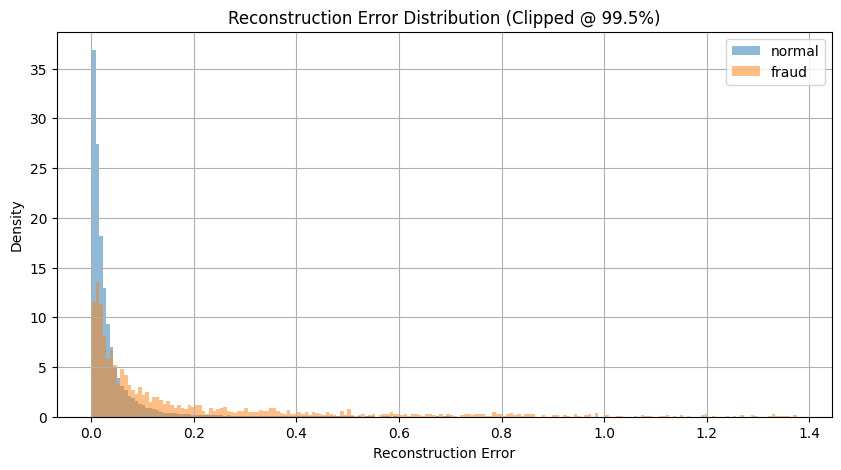

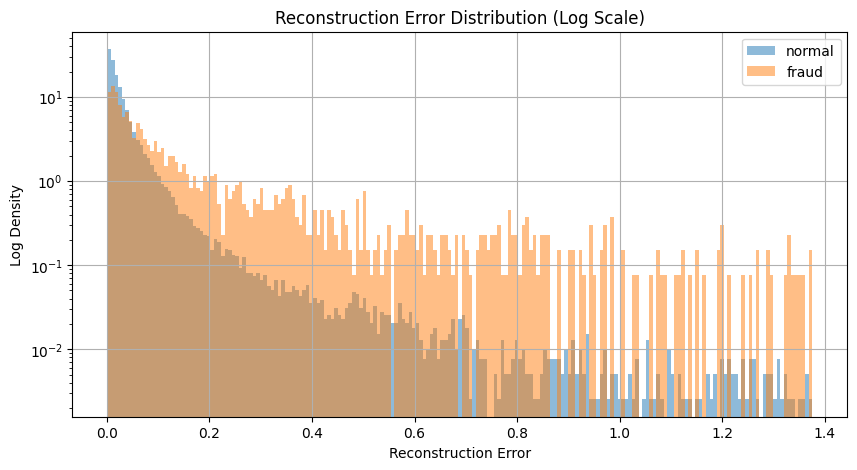

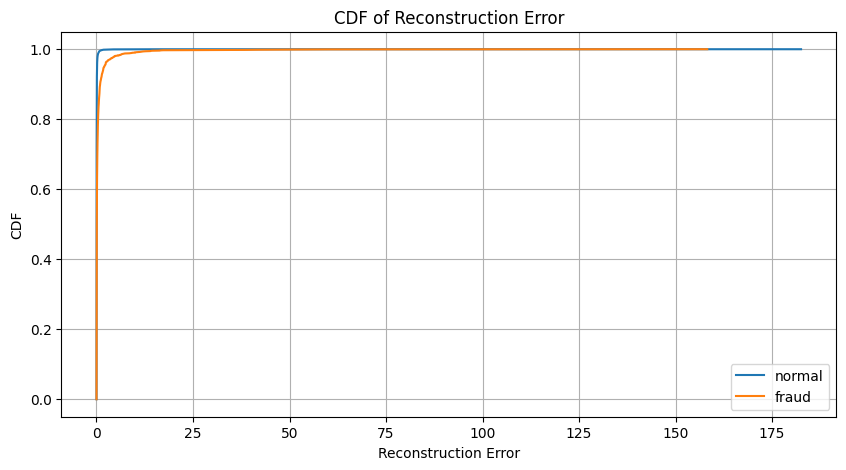

In [25]:
import matplotlib.pyplot as plt

# Combine to define consistent bins
all_errors = np.concatenate([normal, fraud])

bins = np.linspace(all_errors.min(), np.percentile(all_errors, 99.5), 200)

# normal hist
plt.figure(figsize=(10, 5))

plt.hist(normal, bins=bins, alpha=0.5, label="normal", density=True)
plt.hist(fraud, bins=bins, alpha=0.5, label="fraud", density=True)

plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution (Clipped @ 99.5%)")
plt.legend()
plt.grid(True)

plt.show()

# log hist
plt.figure(figsize=(10, 5))

plt.hist(normal, bins=bins, alpha=0.5, label="normal", density=True)
plt.hist(fraud, bins=bins, alpha=0.5, label="fraud", density=True)

plt.yscale("log")  

plt.xlabel("Reconstruction Error")
plt.ylabel("Log Density")
plt.title("Reconstruction Error Distribution (Log Scale)")
plt.legend()
plt.grid(True)

plt.show()

# cdf
def plot_cdf(data, label):
    sorted_data = np.sort(data)
    y = np.linspace(0, 1, len(data))
    plt.plot(sorted_data, y, label=label)

plt.figure(figsize=(10, 5))

plot_cdf(normal, "normal")
plot_cdf(fraud, "fraud")

plt.xlabel("Reconstruction Error")
plt.ylabel("CDF")
plt.title("CDF of Reconstruction Error")
plt.legend()
plt.grid(True)

plt.show()